# 02 - mu measurement on the toys

Pairs every completed S/B run with the SBI/B run of the same variant, seed and fraction, calibrates the exported ratios with C = 1/<r>_B on the fixed background reference, scans NLL(mu) and fits mu toy by toy. numpy and pandas only.

Outputs: `measurements.csv` (one row per toy, also the cache), `aggregates_per_seed.csv`, `aggregates.csv` and `figures/02_*.png`.

## Setup

On Colab the root is the Drive scan folder; locally it is `NSBI_SCAN_ROOT` or `LOCAL_ROOT_DEFAULT`. The saved config is re-rooted with `with_root`.

In [1]:
# --- Setup (Colab or local; numpy/pandas/matplotlib only, no torch needed) ---
import os, sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    def _find_scan_dir():
        """Locate the folder holding nsbi_scan.py on Drive (any folder name works)."""
        import glob as _glob
        cands = ["/content/drive/MyDrive/Research/NSBI/datascan",
                 "/content/drive/MyDrive/Research/NSBI/Training Statistics Scan"]
        for pat in ("/content/drive/MyDrive/Research/NSBI/*/nsbi_scan.py",
                    "/content/drive/MyDrive/*/nsbi_scan.py",
                    "/content/drive/MyDrive/*/*/nsbi_scan.py"):
            if any(os.path.isfile(os.path.join(c, "nsbi_scan.py")) for c in cands):
                break
            cands += sorted({os.path.dirname(p) for p in _glob.glob(pat)})
        for c in cands:
            if os.path.isfile(os.path.join(c, "nsbi_scan.py")):
                return c
        raise FileNotFoundError("nsbi_scan.py not found on Drive: copy the whole scan folder "
                                "(nsbi_scan.py + notebooks) under MyDrive/Research/NSBI/ and rerun this cell")
    SCAN_DIR = _find_scan_dir()
else:
    SCAN_DIR = os.getcwd()
    if not os.path.isfile(os.path.join(SCAN_DIR, "nsbi_scan.py")):
        cand = os.path.dirname(globals().get("__vsc_ipynb_file__", ""))
        if cand and os.path.isfile(os.path.join(cand, "nsbi_scan.py")):
            SCAN_DIR = cand
    assert os.path.isfile(os.path.join(SCAN_DIR, "nsbi_scan.py")), \
        f"nsbi_scan.py not found in {SCAN_DIR!r}; start Jupyter in the 'Training Statistics Scan' folder"
sys.path.insert(0, SCAN_DIR)
import nsbi_scan as ns
print("nsbi_scan from", ns.__file__)

nsbi_scan from /home/ubuntu/datascan/nsbi_scan.py


In [2]:
# ============================ CONFIG (edit here) ============================
LOCAL_ROOT_DEFAULT = r"G:/My Drive/Research/NSBI/datascan"
                                                             # the env var NSBI_SCAN_ROOT overrides it)
FORCE_REMEASURE = False
MEASURE_OFF_DIAGONAL = False
                               # True: also the f_sig != f_sbi attribution pairs (~5 h); run the diagonal first
RUN_SENSITIVITY = True
SENS_SEED = 0                  # seed of the run pairs used in section 6
SANITY_VARIANT, SANITY_SEED, SANITY_TOY = "pretrained", 0, 0   # run pair + toy for the one-toy NLL plot
SAVE_FIGURES = True            # write PNGs to <root>/figures/
# ===========================================================================

In [3]:
root = SCAN_DIR if IN_COLAB else ns.resolve_root(LOCAL_ROOT_DEFAULT)
assert (Path(root) / "scan_config.json").is_file(), \
    f"no scan_config.json under {root!r} - check LOCAL_ROOT_DEFAULT / NSBI_SCAN_ROOT (or run notebook 00)"
cfg = ns.ScanConfig.load(root).with_root(root)   # the saved config carries the Colab root
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
xs = ns.load_cross_sections(cfg)

print("scan root  :", cfg.root)
print("runs dir   :", cfg.runs_dir, "(exists)" if cfg.runs_dir.is_dir() else "(MISSING)")
print("mu grid    : %d points in [%g, %g]; lumi %g fb^-1" % (cfg.mu_steps, cfg.mu_min, cfg.mu_max, cfg.lumi))
print("xs [fb]    :", {k: round(v, 4) for k, v in xs.items()})
print("nu(mu_true):", {m: round(ns.expected_yield(xs, m, cfg.lumi), 1) for m in cfg.mu_true_values})

scan root  : /home/ubuntu/datascan
runs dir   : /home/ubuntu/datascan/runs (exists)
mu grid    : 401 points in [0, 4]; lumi 300 fb^-1
xs [fb]    : {'sig': 0.3166, 'int': -0.6242, 'bkg': 5.9641, 'sbi': 5.6565}
nu(mu_true): {0.4: 1708.8, 2.5: 1730.6}


## 1. Completed runs

A point needs both tasks, so the two task columns should have equal counts.

In [4]:
runs = ns.collect_runs(cfg)
assert len(runs), f"no completed runs under {cfg.runs_dir} - run notebook 01 first"
runs["fit_min"] = runs["fit_seconds"] / 60.0
runs["train_events"] = [ns.training_events_for(cfg, f, t) for f, t in zip(runs.frac, runs.task)]
print(f"{len(runs)} completed runs")

planned = (ns.run_matrix(cfg, variants=["scratch", "pretrained"], seeds=[0])                                     # tier 1
           + ns.run_matrix(cfg, variants=["scratch", "pretrained"], fractions=[0.01, 0.03, 0.10], seeds=[1, 2])  # tier 2
           + ns.run_matrix(cfg, variants=["frozen"], seeds=[0])                                                   # tier 2
           + ns.run_matrix(cfg, variants=["scratch", "pretrained"], fractions=[0.30, 1.0], seeds=[1, 2]))        # tier 3
status = ns.scan_status(cfg, specs=planned)
print(f"{len(planned)} planned runs:", status.status.value_counts().to_dict())
display(pd.crosstab(status.variant, status.status))

# availability: number of seeds per (variant, fraction) and task
avail = (runs.pivot_table(index=["variant", "frac"], columns="task", values="seed", aggfunc="count", fill_value=0)
             .reindex(columns=list(cfg.tasks), fill_value=0))
avail["train_events_sig"] = [ns.training_events_for(cfg, f, "sig_over_bkg") for _, f in avail.index]
display(avail)
unpaired = avail[avail[list(cfg.tasks)].nunique(axis=1) > 1]
if len(unpaired):
    print("WARNING: (variant, frac) points with a different number of seeds per task (some seeds cannot be measured):")
    display(unpaired)

# key per-run diagnostics
diag_cols = ["variant", "task", "frac", "seed", "train_events", "val_auc_full", "val_bce_full",
             "C_ref", "C_sub", "C_val", "closure_chi2_ndf", "best_epoch", "best_step", "epochs_run", "fit_min"]
diag = runs[[c for c in diag_cols if c in runs.columns]]
with pd.option_context("display.max_rows", 200, "display.width", 200):
    display(diag.round(4))

20 completed runs
70 planned runs: {'pending': 50, 'done': 20}


status,done,pending
variant,,
frozen,0,10
pretrained,10,20
scratch,10,20


task             sig_over_bkg  sbi_over_bkg  train_events_sig
variant    frac                                              
pretrained 0.01             1             1             12139
           0.03             1             1             36417
           0.10             1             1            121390
           0.30             1             1            364172
           1.00             1             1           1213905
scratch    0.01             1             1             12139
           0.03             1             1             36417
           0.10             1             1            121390
           0.30             1             1            364172
           1.00             1             1           1213905

,variant,task,frac,seed,train_events,val_auc_full,val_bce_full,C_ref,C_sub,C_val,closure_chi2_ndf,best_epoch,best_step,epochs_run,fit_min
0,pretrained,sbi_over_bkg,0.01,0,23051,0.5056,0.6927,1.0041,1.0044,1.0042,0.1876,13,26000,18,145.2743
1,pretrained,sbi_over_bkg,0.03,0,69152,0.5071,0.6926,1.0037,1.0038,1.0038,0.5306,12,24000,17,133.8996
2,pretrained,sbi_over_bkg,0.10,0,230506,0.5059,0.6927,1.0007,1.0069,1.0072,0.5903,15,30000,20,159.6585
3,pretrained,sbi_over_bkg,0.30,0,691517,0.5058,0.6927,0.9976,0.9977,0.9977,0.4113,10,20000,15,58.5532
4,pretrained,sbi_over_bkg,1.00,0,2305058,0.5058,0.6927,0.9966,0.9966,0.9967,0.2240,12,24000,17,66.5287
5,pretrained,sig_over_bkg,0.01,0,12139,0.8630,0.4637,0.7816,1.0749,0.7831,83.4419,1,2000,6,45.1582
6,pretrained,sig_over_bkg,0.03,0,36417,0.8706,0.4463,0.6830,1.0365,0.6881,92.7621,2,4000,7,55.5624
7,pretrained,sig_over_bkg,0.10,0,121390,0.8758,0.4375,0.8564,0.9854,0.8251,29.3841,5,10000,10,77.8672
8,pretrained,sig_over_bkg,0.30,0,364172,0.8809,0.4288,0.9543,1.0069,0.9344,10.3619,10,20000,15,106.6812
9,pretrained,sig_over_bkg,1.00,0,1213905,0.8799,0.4305,1.0619,1.0579,1.0506,5.5952,7,14000,12,47.0540


## 2. Run diagnostics vs training events

Validation AUC, |C_ref - 1|, m4l closure chi2/ndf and best step per task.

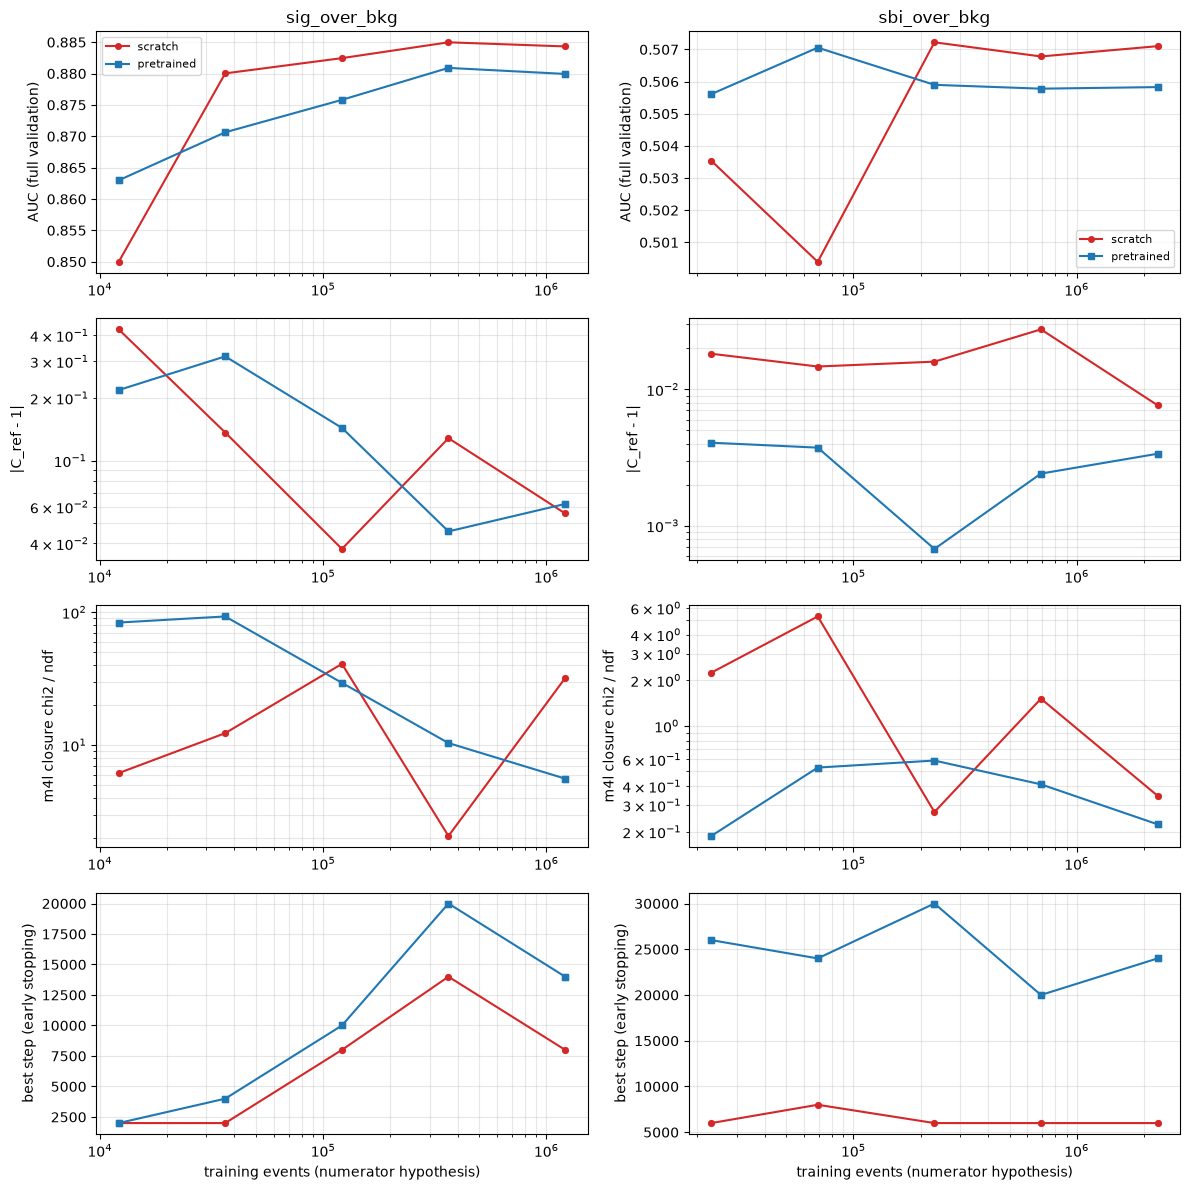

In [5]:
runs["abs_C_ref_m1"] = (runs["C_ref"] - 1.0).abs()
DIAG_METRICS = [("val_auc_full", "AUC (full validation)", False),
                ("abs_C_ref_m1", "|C_ref - 1|", True),
                ("closure_chi2_ndf", "m4l closure chi2 / ndf", True),
                ("best_step", "best step (early stopping)", False)]
VARIANT_STYLE = {"scratch": ("tab:red", "o"), "pretrained": ("tab:blue", "s"), "frozen": ("tab:purple", "^")}

fig, axes = plt.subplots(len(DIAG_METRICS), len(cfg.tasks),
                         figsize=(6.0 * len(cfg.tasks), 3.0 * len(DIAG_METRICS)), squeeze=False)
for j, task in enumerate(cfg.tasks):
    rt = runs[runs.task == task]
    for i, (col, label, logy) in enumerate(DIAG_METRICS):
        ax = axes[i, j]
        for variant in cfg.variants:
            g = rt[rt.variant == variant]
            if not len(g):
                continue
            color, marker = VARIANT_STYLE.get(variant, ("gray", "x"))
            y = g[col].clip(lower=1e-4) if logy else g[col]
            ax.scatter(g.train_events, y, color=color, marker=marker, s=18, alpha=0.5)
            mean = y.groupby(g.train_events).mean()
            ax.plot(mean.index, mean.values, color=color, marker=marker, ms=4, label=variant)
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set_ylabel(label)
        ax.grid(alpha=0.3, which="both")
        if i == 0:
            ax.set_title(task)
            handles, _ = ax.get_legend_handles_labels()
            if handles:
                ax.legend(fontsize=8)
        if i == len(DIAG_METRICS) - 1:
            ax.set_xlabel("training events (numerator hypothesis)")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(cfg.figures_dir / "02_run_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. mu measurement

`MEASURE_OFF_DIAGONAL = True` adds the pairs with f_sig != f_sbi (attribution). About 1 min per pair and mu value on a desktop CPU. The cache is written only at the end of the pass, so do not interrupt the cell; set `FORCE_REMEASURE = True` after re-training a run.

In [6]:
cache_path = Path(root) / "measurements.csv"
if FORCE_REMEASURE and cache_path.exists():
    cache_path.unlink()
    print("removed", cache_path)
pair_keys = ["variant", "seed", "frac_sig", "frac_sbi", "mu_true"]

pairs = (runs[runs.task == "sig_over_bkg"].merge(runs[runs.task == "sbi_over_bkg"], on=["variant", "seed"],
                                                suffixes=("_sig", "_sbi"))[pair_keys[:-1]])
if not MEASURE_OFF_DIAGONAL:
    pairs = pairs[np.isclose(pairs.frac_sig, pairs.frac_sbi)]
old = pd.read_csv(cache_path) if cache_path.exists() else pd.DataFrame(columns=pair_keys)
n_cached = len(pairs.merge(old[pair_keys[:-1]].drop_duplicates(), on=pair_keys[:-1]))
print(f"{len(pairs)} pairs x {len(cfg.mu_true_values)} mu_true ({'all' if MEASURE_OFF_DIAGONAL else 'diagonal only'}); "
      f"{n_cached} pairs cached, {len(pairs) - n_cached} to compute (~{(len(pairs) - n_cached) * len(cfg.mu_true_values)} min)")
if len(old) and not MEASURE_OFF_DIAGONAL:
    assert np.isclose(old.frac_sig, old.frac_sbi).all(), \
        "measurements.csv holds off-diagonal pairs; set MEASURE_OFF_DIAGONAL = True to keep them (cached pairs cost nothing)"

t0 = time.time()
meas = ns.measure_all(cfg, runs, diagonal_only=not MEASURE_OFF_DIAGONAL, calibration="C_ref", cache_path=str(cache_path))
assert len(meas), "no (S/B, SBI/B) pair with matching variant and seed - nothing to measure"
print(f"{len(meas)} toy fits in {time.time() - t0:.0f}s -> {cache_path}")

is_diag = np.isclose(meas.frac_sig, meas.frac_sbi)
print("pairs x mu_true :", meas.groupby(pair_keys).ngroups,
      "| diagonal:", meas[is_diag].groupby(pair_keys).ngroups,
      "| off-diagonal:", meas[~is_diag].groupby(pair_keys).ngroups)
print("diagonal pairs x mu_true per variant:", meas[is_diag].drop_duplicates(pair_keys).groupby("variant").size().to_dict())
print("toys at the scan boundary:", int(meas.at_boundary.sum()),
      "| toys with an open 1-sigma interval:", int((~np.isfinite(meas.lo) | ~np.isfinite(meas.hi)).sum()))
display(meas.head())

10 pairs x 2 mu_true (diagonal only); 7 pairs cached, 3 to compute (~6 min)


960 toy fits in 30s -> /home/ubuntu/datascan/measurements.csv
pairs x mu_true : 20 | diagonal: 20 | off-diagonal: 0
diagonal pairs x mu_true per variant: {'pretrained': 10, 'scratch': 10}
toys at the scan boundary: 174 | toys with an open 1-sigma interval: 175


,variant,seed,frac_sig,frac_sbi,toy,n_nonfinite,mu_hat,lo,hi,width,lo_2sig,hi_2sig,at_boundary,n_nan_t,t_true,covers_1sig,mu_true,calibration,finished_sig,finished_sbi
0,pretrained,0,0.01,0.01,0,0,0.934436,0.915295,1.056386,0.141091,0.858061,1.251107,False,0,14.301010,0.0,0.4,C_ref,2026-09-11 04:14:00,2026-09-12 03:17:12
1,pretrained,0,0.01,0.01,1,0,0.984775,0.960740,1.122294,0.161554,0.916996,1.319414,False,0,24.493168,0.0,0.4,C_ref,2026-09-11 04:14:00,2026-09-12 03:17:12
2,pretrained,0,0.01,0.01,2,0,0.932899,0.885694,1.038962,0.153268,0.362377,1.248584,False,0,3.045119,0.0,0.4,C_ref,2026-09-11 04:14:00,2026-09-12 03:17:12
3,pretrained,0,0.01,0.01,3,0,0.992129,0.949425,1.124418,0.174993,0.944822,1.320408,False,0,19.853802,0.0,0.4,C_ref,2026-09-11 04:14:00,2026-09-12 03:17:12
4,pretrained,0,0.01,0.01,4,0,0.984747,0.972884,1.078265,0.105381,0.772277,1.262908,False,0,14.283916,0.0,0.4,C_ref,2026-09-11 04:14:00,2026-09-12 03:17:12


## 4. Aggregates

Per (variant, seed, f_sig, f_sbi, mu_true) over the 48 toys, then mean and std over seeds.

In [7]:
per_seed, over = ns.aggregate(meas)
per_seed.to_csv(Path(root) / "aggregates_per_seed.csv", index=False)
over.to_csv(Path(root) / "aggregates.csv", index=False)
print("wrote", Path(root) / "aggregates_per_seed.csv", "and", Path(root) / "aggregates.csv")

diag_over = over[np.isclose(over.frac_sig, over.frac_sbi)].copy()
diag_over.insert(1, "frac", diag_over.frac_sig)
diag_over.insert(2, "train_events_sig", [ns.training_events_for(cfg, f, "sig_over_bkg") for f in diag_over.frac])
show_cols = ["mu_true", "variant", "frac", "train_events_sig", "n_seeds", "bias_mean", "bias_seed_std",
             "abs_bias_mean", "halfwidth_mean", "bias_over_sigma_mean", "std_muhat_mean"]
with pd.option_context("display.max_rows", 200, "display.width", 200):
    display(diag_over.sort_values(["mu_true", "variant", "frac"])[show_cols].reset_index(drop=True).round(4))

wrote /home/ubuntu/datascan/aggregates_per_seed.csv and /home/ubuntu/datascan/aggregates.csv


,mu_true,variant,frac,train_events_sig,n_seeds,bias_mean,bias_seed_std,abs_bias_mean,halfwidth_mean,bias_over_sigma_mean,std_muhat_mean
0,0.4,pretrained,0.01,12139,1,0.5306,NaN,0.5306,0.0813,6.5266,0.1362
1,0.4,pretrained,0.03,36417,1,0.5937,NaN,0.5937,0.0595,9.9851,0.0243
2,0.4,pretrained,0.10,121390,1,-0.3859,NaN,0.3859,0.0160,-24.1684,0.0196
3,0.4,pretrained,0.30,364172,1,0.5521,NaN,0.5521,0.1667,3.3118,0.1430
4,0.4,pretrained,1.00,1213905,1,0.0561,NaN,0.0561,0.4042,0.1387,0.1914
5,0.4,scratch,0.01,12139,1,0.2025,NaN,0.2025,0.3907,0.5182,0.0934
6,0.4,scratch,0.03,36417,1,-0.0388,NaN,0.0388,0.2710,-0.1433,0.0151
7,0.4,scratch,0.10,121390,1,-0.1003,NaN,0.1003,0.3493,-0.2871,0.0464
8,0.4,scratch,0.30,364172,1,-0.0182,NaN,0.0182,0.3107,-0.0584,0.0558
9,0.4,scratch,1.00,1213905,1,-0.1187,NaN,0.1187,0.3613,-0.3286,0.0442


## 5. One-toy NLL profile

Total, rate and shape terms for one toy, checked against the cached measurement.

pair: pretrained seed 0 f=100%  C_ref(S/B)=1.0619  C_ref(SBI/B)=0.9966


  mu_true=0.4: toy 0 rows=59228 sum n=1709.0  mu_hat=0.576 [0.173, 0.970]  t(mu_true)=0.47  cached mu_hat=0.576


  mu_true=2.5: toy 0 rows=59228 sum n=1730.2  mu_hat=2.254 [1.964, 2.550]  t(mu_true)=0.70  cached mu_hat=2.254


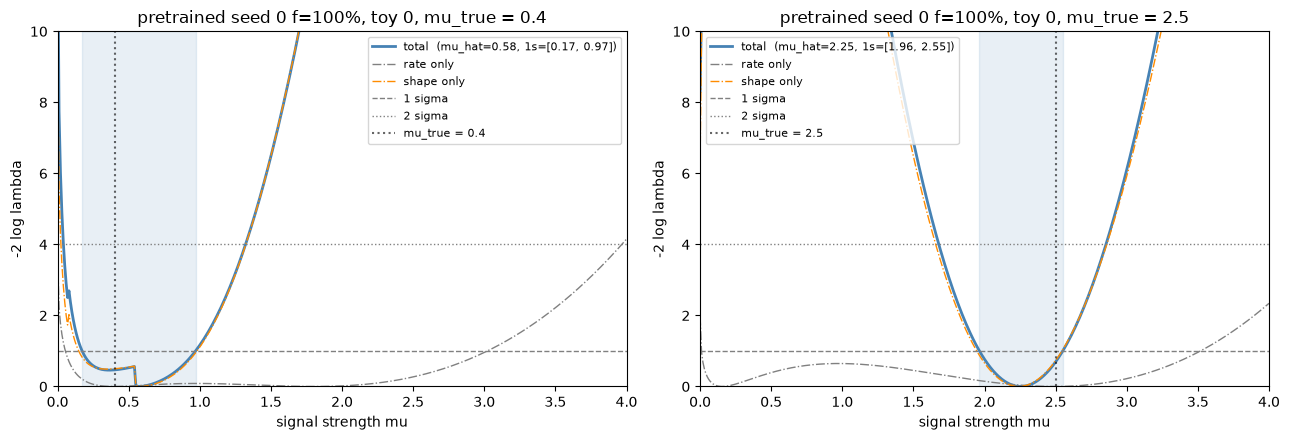

In [8]:
def _diag_pair(runs, variant, seed):   # TODO move to nsbi_scan.py
    """(S/B row, SBI/B row) of variant/seed at the largest fraction where both tasks exist, else None."""
    rv = runs[(runs.variant == variant) & (runs.seed == seed)]
    fr = sorted(set(rv[rv.task == "sig_over_bkg"].frac) & set(rv[rv.task == "sbi_over_bkg"].frac), reverse=True)
    if not fr:
        return None
    pick = lambda task: rv[(rv.task == task) & np.isclose(rv.frac, fr[0])].iloc[0]
    return pick("sig_over_bkg"), pick("sbi_over_bkg")

pair = _diag_pair(runs, SANITY_VARIANT, SANITY_SEED)
if pair is None:
    for (v, s), _ in runs.groupby(["variant", "seed"]):
        pair = _diag_pair(runs, v, s)
        if pair is not None:
            break
assert pair is not None, "no measurable (S/B, SBI/B) pair found"
run_sig, run_sbi = pair
variant, seed, frac = run_sig["variant"], int(run_sig["seed"]), float(run_sig["frac"])
print(f"pair: {variant} seed {seed} f={frac:.0%}  C_ref(S/B)={run_sig['C_ref']:.4f}  C_ref(SBI/B)={run_sbi['C_ref']:.4f}")

mu_grid = cfg.mu_grid
fig, axes = plt.subplots(1, len(cfg.mu_true_values), figsize=(6.5 * len(cfg.mu_true_values), 4.5), squeeze=False)
for ax, mu_true in zip(axes[0], cfg.mu_true_values):
    tag = ns.MU_TAGS[mu_true]
    toys = ns.load_toys(cfg, tag)
    m = toys["toy_id"] == SANITY_TOY
    r_sig = np.load(Path(run_sig["run_dir"]) / f"r_toys_{tag}.npy").astype(np.float64)[m] * float(run_sig["C_ref"])
    r_sbi = np.load(Path(run_sbi["run_dir"]) / f"r_toys_{tag}.npy").astype(np.float64)[m] * float(run_sbi["C_ref"])
    t_tot, t_rate, t_shape = ns.nll_profile(r_sig, r_sbi, toys["n"][m], xs, mu_grid, cfg.lumi)
    fit = ns.fit_mu(mu_grid, t_tot, mu_true)

    cached = meas[(meas.variant == variant) & (meas.seed == seed) & np.isclose(meas.frac_sig, frac)
                  & np.isclose(meas.frac_sbi, frac) & np.isclose(meas.mu_true, mu_true) & (meas.toy == SANITY_TOY)]
    cached_hat = float(cached.mu_hat.iloc[0]) if len(cached) else float("nan")
    print(f"  mu_true={mu_true}: toy {SANITY_TOY} rows={int(m.sum())} sum n={toys['n'][m].sum():.1f}  "
          f"mu_hat={fit['mu_hat']:.3f} [{fit['lo']:.3f}, {fit['hi']:.3f}]  t(mu_true)={fit['t_true']:.2f}  "
          f"cached mu_hat={cached_hat:.3f}")
    if len(cached) and not np.isclose(cached_hat, fit["mu_hat"], atol=1e-6):
        print("  WARNING: cached mu_hat differs from the recomputation - measurements.csv is stale, "
              "set FORCE_REMEASURE = True and rerun section 3")

    ax.plot(mu_grid, t_tot, color="steelblue", lw=2,
            label=f"total  (mu_hat={fit['mu_hat']:.2f}, 1s=[{fit['lo']:.2f}, {fit['hi']:.2f}])")
    ax.plot(mu_grid, t_rate, color="gray", lw=1, ls="-.", label="rate only")
    ax.plot(mu_grid, t_shape, color="darkorange", lw=1, ls="-.", label="shape only")
    if np.isfinite(fit["lo"]) and np.isfinite(fit["hi"]):
        ax.axvspan(fit["lo"], fit["hi"], color="steelblue", alpha=0.12)
    ax.axhline(1.0, color="gray", ls="--", lw=1, label="1 sigma")
    ax.axhline(4.0, color="gray", ls=":", lw=1, label="2 sigma")
    ax.axvline(mu_true, color="black", ls=":", alpha=0.6, label=f"mu_true = {mu_true}")
    ax.set_xlim(cfg.mu_min, cfg.mu_max)
    ax.set_ylim(0, 10)
    ax.set_xlabel("signal strength mu")
    ax.set_ylabel("-2 log lambda")
    ax.set_title(f"{variant} seed {seed} f={frac:.0%}, toy {SANITY_TOY}, mu_true = {mu_true}")
    ax.legend(fontsize=8)
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(cfg.figures_dir / "02_nll_one_toy.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Calibration sensitivity

The diagonal pair at the largest fraction with `C_ref`, `C_sub` and no calibration; `RUN_SENSITIVITY = False` skips it.

In [9]:
if not RUN_SENSITIVITY:
    print("RUN_SENSITIVITY = False: calibration comparison skipped")
else:
    SENS_FRAC = 1.0
    ps_diag = per_seed[np.isclose(per_seed.frac_sig, per_seed.frac_sbi) & (per_seed.seed == SENS_SEED)]
    fr_avail = sorted(set(ps_diag.frac_sig), reverse=True)
    assert fr_avail, f"seed {SENS_SEED} has no measured diagonal pair - set SENS_SEED to a seed of the section 4 table"
    sens_frac = SENS_FRAC if np.isclose(fr_avail, SENS_FRAC).any() else fr_avail[0]
    runs_f = runs[np.isclose(runs.frac, sens_frac) & (runs.seed == SENS_SEED)]

    tables = [ps_diag[np.isclose(ps_diag.frac_sig, sens_frac)].assign(calibration="C_ref")]
    for calib in ("C_sub", "none"):
        t0 = time.time()
        m_c = ns.measure_all(cfg, runs_f, diagonal_only=True, calibration=calib)
        if not len(m_c):
            print(f"{calib}: no measurable pair at f={sens_frac:.0%} for seed {SENS_SEED}")
            continue
        ps_c, _ = ns.aggregate(m_c)
        tables.append(ps_c.assign(calibration=calib))
        print(f"{calib}: {len(m_c)} toy fits in {time.time() - t0:.0f}s")
    sens = pd.concat(tables, ignore_index=True)

    print(f"calibration sensitivity at f = {sens_frac:.0%}, seed {SENS_SEED} (one run pair per variant)")
    sens_tab = (sens.pivot_table(index=["mu_true", "variant"], columns="calibration",
                                 values=["bias", "bias_over_sigma", "mean_halfwidth"])
                    .reindex(columns=["C_ref", "C_sub", "none"], level=1))
    display(sens_tab.round(4))

    # the factors themselves for these runs, per variant and task
    display(runs_f.set_index(["variant", "task"])[["C_ref", "C_sub", "C_val"]].sort_index().round(4))

C_sub: 192 toy fits in 20s


none: 192 toy fits in 20s
calibration sensitivity at f = 100%, seed 0 (one run pair per variant)


bias                 bias_over_sigma                  \
calibration          C_ref   C_sub    none           C_ref   C_sub    none   
mu_true variant                                                              
0.4     pretrained  0.0561  0.0330  0.3868          0.1387  0.0850  1.2073   
        scratch    -0.1187 -0.1209  0.7170         -0.3286 -0.3404  2.5132   
2.5     pretrained -0.1733 -0.1887 -0.2596         -0.5957 -0.6481 -0.8900   
        scratch    -0.1778 -0.1803 -0.0535         -0.6336 -0.6428 -0.1897   

                   mean_halfwidth                  
calibration                 C_ref   C_sub    none  
mu_true variant                                    
0.4     pretrained         0.4042  0.3877  0.3204  
        scratch            0.3613  0.3552  0.2853  
2.5     pretrained         0.2910  0.2911  0.2917  
        scratch            0.2805  0.2806  0.2820

C_ref   C_sub   C_val
variant    task                                
pretrained sbi_over_bkg  0.9966  0.9966  0.9967
           sig_over_bkg  1.0619  1.0579  1.0506
scratch    sbi_over_bkg  0.9924  0.9924  0.9925
           sig_over_bkg  1.0557  1.0552  1.0550

## Caveats

The toys are weighted MC subsets without Poisson fluctuation: the toy spread is MC noise, not coverage, and `frac_covering` is only a sanity number. The same toys serve every run, so the seed spread is the error bar that matters. C is one global scale: it fixes the normalisation of r, not its shape.